In [228]:
import numpy as np
import pandas as pd
import datetime 
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
claims = pd.read_csv('D:\AnalytixLabs\Case Studies\Python Case Study\Case Study 3 - Insurance Claims Case Study\claims.csv')

In [81]:
cust = pd.read_csv('D:\AnalytixLabs\Case Studies\Python Case Study\Case Study 3 - Insurance Claims Case Study\cust_demographics.csv')

In [82]:
claims.head()

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,54004764,21868593,Driver error,11/27/2017,Auto,No,Material only,$2980,1.0,No
1,33985796,75740424,Crime,10/03/2018,Home,Unknown,Material only,$2980,3.0,No
2,53522022,30308357,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1.0,Yes
3,13015401,47830476,Natural causes,06/17/2018,Auto,No,Material only,$1680,1.0,No
4,22890252,19269962,Crime,01/13/2018,Auto,No,Material only,$2680,1.0,No


In [83]:
cust.head()

,CUST_ID,gender,DateOfBirth,State,Contact,Segment
0,21868593,Female,12-Jan-79,VT,789-916-8172,Platinum
1,75740424,Female,13-Jan-70,ME,265-543-1264,Silver
2,30308357,Female,11-Mar-84,TN,798-631-4758,Silver
3,47830476,Female,01-May-86,MA,413-187-7945,Silver
4,19269962,Male,13-May-77,NV,956-871-8691,Gold


In [84]:
claims.shape

(1100, 10)

In [85]:
cust.shape

(1085, 6)

In [86]:
claims.columns

Index(['claim_id', 'customer_id', 'incident_cause', 'claim_date', 'claim_area',
       'police_report', 'claim_type', 'claim_amount', 'total_policy_claims',
       'fraudulent'],
      dtype='object')

In [87]:
cust.columns

Index(['CUST_ID', 'gender', 'DateOfBirth', 'State', 'Contact', 'Segment'], dtype='object')

In [88]:
df = pd.merge(claims, cust, left_on='customer_id', right_on = 'CUST_ID', how='inner')

In [89]:
df.head()

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,CUST_ID,gender,DateOfBirth,State,Contact,Segment
0,54004764,21868593,Driver error,11/27/2017,Auto,No,Material only,$2980,1.0,No,21868593,Female,12-Jan-79,VT,789-916-8172,Platinum
1,33985796,75740424,Crime,10/03/2018,Home,Unknown,Material only,$2980,3.0,No,75740424,Female,13-Jan-70,ME,265-543-1264,Silver
2,53522022,30308357,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1.0,Yes,30308357,Female,11-Mar-84,TN,798-631-4758,Silver
3,13015401,47830476,Natural causes,06/17/2018,Auto,No,Material only,$1680,1.0,No,47830476,Female,01-May-86,MA,413-187-7945,Silver
4,22890252,19269962,Crime,01/13/2018,Auto,No,Material only,$2680,1.0,No,19269962,Male,13-May-77,NV,956-871-8691,Gold


In [90]:
df.shape

(1085, 16)

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   claim_id             1085 non-null   int64  
 1   customer_id          1085 non-null   int64  
 2   incident_cause       1085 non-null   object 
 3   claim_date           1085 non-null   object 
 4   claim_area           1085 non-null   object 
 5   police_report        1085 non-null   object 
 6   claim_type           1085 non-null   object 
 7   claim_amount         1020 non-null   object 
 8   total_policy_claims  1075 non-null   float64
 9   fraudulent           1085 non-null   object 
 10  CUST_ID              1085 non-null   int64  
 11  gender               1085 non-null   object 
 12  DateOfBirth          1085 non-null   object 
 13  State                1085 non-null   object 
 14  Contact              1085 non-null   object 
 15  Segment              1085 non-null   o

In [92]:
df.drop(columns= 'CUST_ID', inplace=True)

In [93]:
df

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment
0,54004764,21868593,Driver error,11/27/2017,Auto,No,Material only,$2980,1.0,No,Female,12-Jan-79,VT,789-916-8172,Platinum
1,33985796,75740424,Crime,10/03/2018,Home,Unknown,Material only,$2980,3.0,No,Female,13-Jan-70,ME,265-543-1264,Silver
2,53522022,30308357,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1.0,Yes,Female,11-Mar-84,TN,798-631-4758,Silver
3,13015401,47830476,Natural causes,06/17/2018,Auto,No,Material only,$1680,1.0,No,Female,01-May-86,MA,413-187-7945,Silver
4,22890252,19269962,Crime,01/13/2018,Auto,No,Material only,$2680,1.0,No,Male,13-May-77,NV,956-871-8691,Gold
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1080,62020796,79539873,Other driver error,09/06/2018,Auto,Yes,Material only,$1770,1.0,No,Female,15-Mar-81,ND,459-425-4319,Platinum
1081,63269067,42364152,Other causes,05/09/2017,Home,No,Material only,$2800,1.0,No,Female,07-Jul-96,ID,529-462-1635,Silver
1082,22690595,19888166,Other driver error,05/15/2017,Auto,Yes,Injury only,$33080,2.0,No,Male,11-Apr-90,WI,712-651-9613,Gold
1083,12376894,11256802,Other driver error,04/18/2017,Auto,No,Material only,$2840,4.0,No,Female,22-Oct-64,LA,469-345-5617,Silver


In [94]:
df['claim_amount'] = df['claim_amount'].str.replace(r'[\$,]','', regex = True)

In [95]:
df['claim_amount'] = df['claim_amount'].str.strip()

In [96]:
df['claim_amount']

0         2980
1         2980
2       3369.5
3         1680
4         2680
         ...  
1080      1770
1081      2800
1082     33080
1083      2840
1084      1490
Name: claim_amount, Length: 1085, dtype: object

In [97]:
df['claim_amount'] = pd.to_numeric(df['claim_amount'], errors='coerce')

In [98]:
df.head()

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment
0,54004764,21868593,Driver error,11/27/2017,Auto,No,Material only,2980.0,1.0,No,Female,12-Jan-79,VT,789-916-8172,Platinum
1,33985796,75740424,Crime,10/03/2018,Home,Unknown,Material only,2980.0,3.0,No,Female,13-Jan-70,ME,265-543-1264,Silver
2,53522022,30308357,Other driver error,02/02/2018,Auto,No,Material only,3369.5,1.0,Yes,Female,11-Mar-84,TN,798-631-4758,Silver
3,13015401,47830476,Natural causes,06/17/2018,Auto,No,Material only,1680.0,1.0,No,Female,01-May-86,MA,413-187-7945,Silver
4,22890252,19269962,Crime,01/13/2018,Auto,No,Material only,2680.0,1.0,No,Male,13-May-77,NV,956-871-8691,Gold


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   claim_id             1085 non-null   int64  
 1   customer_id          1085 non-null   int64  
 2   incident_cause       1085 non-null   object 
 3   claim_date           1085 non-null   object 
 4   claim_area           1085 non-null   object 
 5   police_report        1085 non-null   object 
 6   claim_type           1085 non-null   object 
 7   claim_amount         1020 non-null   float64
 8   total_policy_claims  1075 non-null   float64
 9   fraudulent           1085 non-null   object 
 10  gender               1085 non-null   object 
 11  DateOfBirth          1085 non-null   object 
 12  State                1085 non-null   object 
 13  Contact              1085 non-null   object 
 14  Segment              1085 non-null   object 
dtypes: float64(2), int64(2), object(11)
me

In [100]:
df['claim_date'] = pd.to_datetime(df['claim_date'], format='%m/%d/%Y')

In [101]:
df['DateOfBirth'] = pd.to_datetime(df['DateOfBirth'],format='%d-%b-%y')

In [102]:
df['DateOfBirth'].head()

0   1979-01-12
1   1970-01-13
2   1984-03-11
3   1986-05-01
4   1977-05-13
Name: DateOfBirth, dtype: datetime64[ns]

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   claim_id             1085 non-null   int64         
 1   customer_id          1085 non-null   int64         
 2   incident_cause       1085 non-null   object        
 3   claim_date           1085 non-null   datetime64[ns]
 4   claim_area           1085 non-null   object        
 5   police_report        1085 non-null   object        
 6   claim_type           1085 non-null   object        
 7   claim_amount         1020 non-null   float64       
 8   total_policy_claims  1075 non-null   float64       
 9   fraudulent           1085 non-null   object        
 10  gender               1085 non-null   object        
 11  DateOfBirth          1085 non-null   datetime64[ns]
 12  State                1085 non-null   object        
 13  Contact              1085 non-nul

In [104]:
df.head()

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment
0,54004764,21868593,Driver error,2017-11-27,Auto,No,Material only,2980.0,1.0,No,Female,1979-01-12,VT,789-916-8172,Platinum
1,33985796,75740424,Crime,2018-10-03,Home,Unknown,Material only,2980.0,3.0,No,Female,1970-01-13,ME,265-543-1264,Silver
2,53522022,30308357,Other driver error,2018-02-02,Auto,No,Material only,3369.5,1.0,Yes,Female,1984-03-11,TN,798-631-4758,Silver
3,13015401,47830476,Natural causes,2018-06-17,Auto,No,Material only,1680.0,1.0,No,Female,1986-05-01,MA,413-187-7945,Silver
4,22890252,19269962,Crime,2018-01-13,Auto,No,Material only,2680.0,1.0,No,Male,1977-05-13,NV,956-871-8691,Gold


In [105]:
df['claim_type'].value_counts()

claim_type
Material only          653
Material and injury    237
Injury only            195
Name: count, dtype: int64

In [106]:
df['police_report'].value_counts()

police_report
No         621
Unknown    296
Yes        168
Name: count, dtype: int64

In [107]:
df['Alert_flag'] = ((df['claim_type'] == 'Injury only') & (df['police_report'] == 'No')).astype(int)

In [108]:
df

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment,Alert_flag
0,54004764,21868593,Driver error,2017-11-27,Auto,No,Material only,2980.0,1.0,No,Female,1979-01-12,VT,789-916-8172,Platinum,0
1,33985796,75740424,Crime,2018-10-03,Home,Unknown,Material only,2980.0,3.0,No,Female,1970-01-13,ME,265-543-1264,Silver,0
2,53522022,30308357,Other driver error,2018-02-02,Auto,No,Material only,3369.5,1.0,Yes,Female,1984-03-11,TN,798-631-4758,Silver,0
3,13015401,47830476,Natural causes,2018-06-17,Auto,No,Material only,1680.0,1.0,No,Female,1986-05-01,MA,413-187-7945,Silver,0
4,22890252,19269962,Crime,2018-01-13,Auto,No,Material only,2680.0,1.0,No,Male,1977-05-13,NV,956-871-8691,Gold,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1080,62020796,79539873,Other driver error,2018-09-06,Auto,Yes,Material only,1770.0,1.0,No,Female,1981-03-15,ND,459-425-4319,Platinum,0
1081,63269067,42364152,Other causes,2017-05-09,Home,No,Material only,2800.0,1.0,No,Female,1996-07-07,ID,529-462-1635,Silver,0
1082,22690595,19888166,Other driver error,2017-05-15,Auto,Yes,Injury only,33080.0,2.0,No,Male,1990-04-11,WI,712-651-9613,Gold,0
1083,12376894,11256802,Other driver error,2017-04-18,Auto,No,Material only,2840.0,4.0,No,Female,2064-10-22,LA,469-345-5617,Silver,0


In [109]:
df['Alert_flag'].value_counts()

Alert_flag
0    1025
1      60
Name: count, dtype: int64

In [110]:
df[['claim_type', 'police_report', 'Alert_flag']].head()

,claim_type,police_report,Alert_flag
0,Material only,No,0
1,Material only,Unknown,0
2,Material only,No,0
3,Material only,No,0
4,Material only,No,0


In [111]:
df[df['Alert_flag'] == 1].shape

(60, 16)

In [112]:
df = df.sort_values(by= 'claim_date', ascending= False)

In [113]:
df = df.drop_duplicates(subset='customer_id', keep= 'first')

In [114]:
df

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment,Alert_flag
751,25213498,28932340,Driver error,2018-10-30,Auto,Unknown,Material only,NaN,1.0,No,Male,1996-01-05,LA,652-265-8231,Gold,0
1077,91386759,65208809,Natural causes,2018-10-30,Auto,No,Material only,2290.0,1.0,No,Male,2064-04-22,VA,286-128-6132,Platinum,0
222,49735712,17682060,Crime,2018-10-30,Home,Unknown,Material and injury,17020.0,1.0,No,Female,1974-11-21,NV,186-195-3465,Gold,0
234,52377605,40480522,Driver error,2018-10-30,Auto,Unknown,Material and injury,26310.0,1.0,No,Female,1984-05-30,NV,739-259-6835,Gold,0
282,99775483,93915431,Other causes,2018-10-30,Auto,No,Material and injury,42124.5,1.0,Yes,Male,2067-09-08,ME,134-785-1687,Gold,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,58878919,29323970,Driver error,2017-01-01,Auto,Unknown,Material only,1840.0,1.0,Yes,Male,1971-03-03,NE,783-653-9163,Gold,0
308,9476314,65176092,Other causes,2017-01-01,Auto,No,Material and injury,37290.0,3.0,No,Male,1975-11-23,NC,651-379-2486,Silver,0
905,42280334,42664554,Other causes,2017-01-01,Auto,No,Injury only,27670.0,1.0,No,Female,1993-08-13,TN,396-973-2531,Gold,1
191,23636125,64840478,Other driver error,2017-01-01,Auto,Unknown,Material and injury,17290.0,1.0,No,Female,1974-02-14,NM,918-174-7461,Silver,0


In [115]:
df.isnull().sum()

claim_id                0
customer_id             0
incident_cause          0
claim_date              0
claim_area              0
police_report           0
claim_type              0
claim_amount           65
total_policy_claims    10
fraudulent              0
gender                  0
DateOfBirth             0
State                   0
Contact                 0
Segment                 0
Alert_flag              0
dtype: int64

In [116]:
df.dtypes

claim_id                        int64
customer_id                     int64
incident_cause                 object
claim_date             datetime64[ns]
claim_area                     object
police_report                  object
claim_type                     object
claim_amount                  float64
total_policy_claims           float64
fraudulent                     object
gender                         object
DateOfBirth            datetime64[ns]
State                          object
Contact                        object
Segment                        object
Alert_flag                      int64
dtype: object

In [117]:
# handling missing values
num_cols = df.select_dtypes(include= ['int64', 'float64']).columns

In [118]:
num_cols

Index(['claim_id', 'customer_id', 'claim_amount', 'total_policy_claims',
       'Alert_flag'],
      dtype='object')

In [119]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

In [120]:
df

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment,Alert_flag
751,25213498,28932340,Driver error,2018-10-30,Auto,Unknown,Material only,12501.726555,1.0,No,Male,1996-01-05,LA,652-265-8231,Gold,0
1077,91386759,65208809,Natural causes,2018-10-30,Auto,No,Material only,2290.000000,1.0,No,Male,2064-04-22,VA,286-128-6132,Platinum,0
222,49735712,17682060,Crime,2018-10-30,Home,Unknown,Material and injury,17020.000000,1.0,No,Female,1974-11-21,NV,186-195-3465,Gold,0
234,52377605,40480522,Driver error,2018-10-30,Auto,Unknown,Material and injury,26310.000000,1.0,No,Female,1984-05-30,NV,739-259-6835,Gold,0
282,99775483,93915431,Other causes,2018-10-30,Auto,No,Material and injury,42124.500000,1.0,Yes,Male,2067-09-08,ME,134-785-1687,Gold,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,58878919,29323970,Driver error,2017-01-01,Auto,Unknown,Material only,1840.000000,1.0,Yes,Male,1971-03-03,NE,783-653-9163,Gold,0
308,9476314,65176092,Other causes,2017-01-01,Auto,No,Material and injury,37290.000000,3.0,No,Male,1975-11-23,NC,651-379-2486,Silver,0
905,42280334,42664554,Other causes,2017-01-01,Auto,No,Injury only,27670.000000,1.0,No,Female,1993-08-13,TN,396-973-2531,Gold,1
191,23636125,64840478,Other driver error,2017-01-01,Auto,Unknown,Material and injury,17290.000000,1.0,No,Female,1974-02-14,NM,918-174-7461,Silver,0


In [121]:
df.isnull().sum()

claim_id               0
customer_id            0
incident_cause         0
claim_date             0
claim_area             0
police_report          0
claim_type             0
claim_amount           0
total_policy_claims    0
fraudulent             0
gender                 0
DateOfBirth            0
State                  0
Contact                0
Segment                0
Alert_flag             0
dtype: int64

In [122]:
# Categorizing the age groups 

In [123]:
df

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment,Alert_flag
751,25213498,28932340,Driver error,2018-10-30,Auto,Unknown,Material only,12501.726555,1.0,No,Male,1996-01-05,LA,652-265-8231,Gold,0
1077,91386759,65208809,Natural causes,2018-10-30,Auto,No,Material only,2290.000000,1.0,No,Male,2064-04-22,VA,286-128-6132,Platinum,0
222,49735712,17682060,Crime,2018-10-30,Home,Unknown,Material and injury,17020.000000,1.0,No,Female,1974-11-21,NV,186-195-3465,Gold,0
234,52377605,40480522,Driver error,2018-10-30,Auto,Unknown,Material and injury,26310.000000,1.0,No,Female,1984-05-30,NV,739-259-6835,Gold,0
282,99775483,93915431,Other causes,2018-10-30,Auto,No,Material and injury,42124.500000,1.0,Yes,Male,2067-09-08,ME,134-785-1687,Gold,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,58878919,29323970,Driver error,2017-01-01,Auto,Unknown,Material only,1840.000000,1.0,Yes,Male,1971-03-03,NE,783-653-9163,Gold,0
308,9476314,65176092,Other causes,2017-01-01,Auto,No,Material and injury,37290.000000,3.0,No,Male,1975-11-23,NC,651-379-2486,Silver,0
905,42280334,42664554,Other causes,2017-01-01,Auto,No,Injury only,27670.000000,1.0,No,Female,1993-08-13,TN,396-973-2531,Gold,1
191,23636125,64840478,Other driver error,2017-01-01,Auto,Unknown,Material and injury,17290.000000,1.0,No,Female,1974-02-14,NM,918-174-7461,Silver,0


In [124]:
df[df['DateOfBirth'] > pd.Timestamp.today()]

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment,Alert_flag
1077,91386759,65208809,Natural causes,2018-10-30,Auto,No,Material only,2290.0,1.0,No,Male,2064-04-22,VA,286-128-6132,Platinum,0
282,99775483,93915431,Other causes,2018-10-30,Auto,No,Material and injury,42124.5,1.0,Yes,Male,2067-09-08,ME,134-785-1687,Gold,0
1055,43042986,58451506,Natural causes,2018-10-30,Auto,No,Material only,2420.0,1.0,No,Male,2068-04-22,FL,673-574-7823,Gold,0
977,9261301,53042145,Other causes,2018-10-23,Auto,Unknown,Material only,2553.0,4.0,Yes,Female,2064-10-04,TN,139-746-7128,Platinum,0
728,26678377,28590552,Other causes,2018-10-23,Auto,Unknown,Material and injury,25160.0,1.0,No,Female,2064-01-10,TN,189-813-7561,Silver,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,30422665,70088729,Driver error,2017-01-07,Home,No,Material only,1552.5,1.0,Yes,Male,2062-12-06,WI,453-475-2863,Silver,0
840,58440592,18426154,Other causes,2017-01-07,Auto,Yes,Material and injury,21590.0,1.0,No,Male,2060-06-07,NJ,879-485-1945,Gold,0
955,85590604,41128407,Other causes,2017-01-07,Auto,No,Injury only,36670.0,2.0,No,Male,2066-07-09,SD,812-324-7932,Silver,1
291,11682102,24579061,Natural causes,2017-01-07,Auto,No,Material only,1770.0,1.0,No,Female,2067-11-24,IN,763-365-2837,Platinum,0


In [125]:
df.loc[df['DateOfBirth'] > pd.Timestamp.today(), 'DateOfBirth'] -= pd.DateOffset(years=100)

In [126]:
df[df['DateOfBirth'] > pd.Timestamp.today()]

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment,Alert_flag


In [128]:
df['Age'] = (pd.Timestamp.today() - df['DateOfBirth']).dt.days // 365

In [129]:
df

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment,Alert_flag,Age
751,25213498,28932340,Driver error,2018-10-30,Auto,Unknown,Material only,12501.726555,1.0,No,Male,1996-01-05,LA,652-265-8231,Gold,0,30
1077,91386759,65208809,Natural causes,2018-10-30,Auto,No,Material only,2290.000000,1.0,No,Male,1964-04-22,VA,286-128-6132,Platinum,0,62
222,49735712,17682060,Crime,2018-10-30,Home,Unknown,Material and injury,17020.000000,1.0,No,Female,1974-11-21,NV,186-195-3465,Gold,0,51
234,52377605,40480522,Driver error,2018-10-30,Auto,Unknown,Material and injury,26310.000000,1.0,No,Female,1984-05-30,NV,739-259-6835,Gold,0,41
282,99775483,93915431,Other causes,2018-10-30,Auto,No,Material and injury,42124.500000,1.0,Yes,Male,1967-09-08,ME,134-785-1687,Gold,0,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,58878919,29323970,Driver error,2017-01-01,Auto,Unknown,Material only,1840.000000,1.0,Yes,Male,1971-03-03,NE,783-653-9163,Gold,0,55
308,9476314,65176092,Other causes,2017-01-01,Auto,No,Material and injury,37290.000000,3.0,No,Male,1975-11-23,NC,651-379-2486,Silver,0,50
905,42280334,42664554,Other causes,2017-01-01,Auto,No,Injury only,27670.000000,1.0,No,Female,1993-08-13,TN,396-973-2531,Gold,1,32
191,23636125,64840478,Other driver error,2017-01-01,Auto,Unknown,Material and injury,17290.000000,1.0,No,Female,1974-02-14,NM,918-174-7461,Silver,0,52


In [130]:
df[df['Age'] < 0]

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment,Alert_flag,Age


In [133]:
# Categorized the customers age in different groups.

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 18, 30, 60, 100],
    labels=['Children', 'Youth', 'Adult', 'Senior'],
    right=False
)

In [135]:
df

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment,Alert_flag,Age,Age_Group
751,25213498,28932340,Driver error,2018-10-30,Auto,Unknown,Material only,12501.726555,1.0,No,Male,1996-01-05,LA,652-265-8231,Gold,0,30,Adult
1077,91386759,65208809,Natural causes,2018-10-30,Auto,No,Material only,2290.000000,1.0,No,Male,1964-04-22,VA,286-128-6132,Platinum,0,62,Senior
222,49735712,17682060,Crime,2018-10-30,Home,Unknown,Material and injury,17020.000000,1.0,No,Female,1974-11-21,NV,186-195-3465,Gold,0,51,Adult
234,52377605,40480522,Driver error,2018-10-30,Auto,Unknown,Material and injury,26310.000000,1.0,No,Female,1984-05-30,NV,739-259-6835,Gold,0,41,Adult
282,99775483,93915431,Other causes,2018-10-30,Auto,No,Material and injury,42124.500000,1.0,Yes,Male,1967-09-08,ME,134-785-1687,Gold,0,58,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,58878919,29323970,Driver error,2017-01-01,Auto,Unknown,Material only,1840.000000,1.0,Yes,Male,1971-03-03,NE,783-653-9163,Gold,0,55,Adult
308,9476314,65176092,Other causes,2017-01-01,Auto,No,Material and injury,37290.000000,3.0,No,Male,1975-11-23,NC,651-379-2486,Silver,0,50,Adult
905,42280334,42664554,Other causes,2017-01-01,Auto,No,Injury only,27670.000000,1.0,No,Female,1993-08-13,TN,396-973-2531,Gold,1,32,Adult
191,23636125,64840478,Other driver error,2017-01-01,Auto,Unknown,Material and injury,17290.000000,1.0,No,Female,1974-02-14,NM,918-174-7461,Silver,0,52,Adult


In [139]:
# calculating average amount claimed by customers from various segments

df.groupby('Segment')['claim_amount'].mean()

Segment
Gold        12846.400227
Platinum    12371.654843
Silver      12267.859374
Name: claim_amount, dtype: float64

In [140]:
# total claim amount based on incident cause for all the claims that have been done at least 20 days prior to 1st October 2018

In [141]:
cutoff_date = pd.Timestamp('2018-10-01') - pd.Timedelta(days = 20)

In [142]:
cutoff_date

Timestamp('2018-09-11 00:00:00')

In [143]:
df_filtered = df[df['claim_date'] <= cutoff_date]

In [144]:
df_filtered

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment,Alert_flag,Age,Age_Group
963,35136402,98401399,Natural causes,2018-09-06,Auto,Unknown,Injury only,24900.0,1.0,No,Female,1968-10-07,IA,219-593-1674,Silver,0,57,Adult
956,3110549,75884493,Other driver error,2018-09-06,Auto,Yes,Material and injury,35310.0,6.0,No,Female,1969-07-27,VT,196-435-7259,Gold,0,56,Adult
707,36047575,50560987,Other causes,2018-09-06,Auto,Unknown,Material and injury,21700.0,3.0,No,Male,1971-01-28,NM,927-641-9614,Platinum,0,55,Adult
1080,62020796,79539873,Other driver error,2018-09-06,Auto,Yes,Material only,1770.0,1.0,No,Female,1981-03-15,ND,459-425-4319,Platinum,0,45,Adult
410,75623323,7612094,Natural causes,2018-09-06,Auto,No,Material only,2771.5,1.0,Yes,Male,1983-08-26,UT,145-734-4176,Gold,0,42,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,58878919,29323970,Driver error,2017-01-01,Auto,Unknown,Material only,1840.0,1.0,Yes,Male,1971-03-03,NE,783-653-9163,Gold,0,55,Adult
308,9476314,65176092,Other causes,2017-01-01,Auto,No,Material and injury,37290.0,3.0,No,Male,1975-11-23,NC,651-379-2486,Silver,0,50,Adult
905,42280334,42664554,Other causes,2017-01-01,Auto,No,Injury only,27670.0,1.0,No,Female,1993-08-13,TN,396-973-2531,Gold,1,32,Adult
191,23636125,64840478,Other driver error,2017-01-01,Auto,Unknown,Material and injury,17290.0,1.0,No,Female,1974-02-14,NM,918-174-7461,Silver,0,52,Adult


In [146]:
result =  df_filtered.groupby('incident_cause')['claim_amount'].sum()

In [147]:
result

incident_cause
Crime                 7.219386e+05
Driver error          3.315851e+06
Natural causes        1.312987e+06
Other causes          3.723152e+06
Other driver error    3.277536e+06
Name: claim_amount, dtype: float64

In [148]:
# Total number of adults from TX,DE and AK who claimed insurance for driver related issues

In [150]:
df['incident_cause'].value_counts()

incident_cause
Other causes          284
Driver error          259
Other driver error    243
Natural causes        185
Crime                 107
Name: count, dtype: int64

In [151]:
df_filtered = df[
    (df['Age_Group'] == 'Adult') &
    (df['State'].isin(['TX', 'DE', 'AK'])) &
    (df['incident_cause'].isin(['Driver error', 'Other driver error']))]

In [152]:
df_filtered

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment,Alert_flag,Age,Age_Group
318,87329176,77510822,Other driver error,2018-10-30,Auto,Unknown,Material only,12501.726555,2.0,No,Female,1986-03-18,AK,436-934-7156,Silver,0,40,Adult
372,92399694,92971195,Other driver error,2018-09-26,Home,No,Material only,1140.000000,1.0,No,Male,1975-02-02,DE,892-173-4657,Gold,0,51,Adult
114,65335959,61810954,Other driver error,2018-09-19,Auto,Unknown,Material and injury,36620.000000,1.0,No,Male,1969-05-18,TX,724-493-6179,Silver,0,56,Adult
607,54642809,39959491,Driver error,2018-09-06,Auto,Unknown,Material only,2720.000000,1.0,No,Female,1995-04-07,DE,139-742-5417,Silver,0,31,Adult
183,21550521,68772500,Driver error,2018-08-30,Auto,Unknown,Material only,2320.000000,1.0,No,Male,1989-11-10,TX,562-259-5432,Silver,0,36,Adult
547,86096444,65899365,Driver error,2018-07-14,Auto,No,Material and injury,34160.000000,1.0,No,Female,1973-07-25,TX,135-971-8567,Platinum,0,52,Adult
242,7238381,684748,Other driver error,2018-07-14,Auto,No,Material only,2920.000000,2.0,No,Male,1977-08-03,AK,613-385-2863,Gold,0,48,Adult
926,7136079,29903212,Driver error,2018-06-17,Auto,No,Material only,2668.000000,2.0,Yes,Male,1989-12-16,DE,279-918-3268,Platinum,0,36,Adult
97,4506676,2632562,Other driver error,2018-05-14,Home,Unknown,Material only,1400.000000,1.0,No,Female,1985-12-14,AK,498-597-9658,Platinum,0,40,Adult
620,78221963,84147585,Driver error,2018-04-10,Auto,Yes,Injury only,14430.000000,4.0,No,Male,1972-10-18,AK,743-569-4783,Gold,0,53,Adult


In [153]:
count = df_filtered.shape[0]

In [154]:
count

27

In [155]:
# Pie chart between the aggregated value of claim based on gender and segment

In [156]:
grouped = df.groupby(['gender', 'Segment'])['claim_amount'].sum()

In [157]:
grouped

gender  Segment 
Female  Gold        2.110045e+06
        Platinum    2.369722e+06
        Silver      1.897545e+06
Male    Gold        2.655970e+06
        Platinum    2.096445e+06
        Silver      2.347134e+06
Name: claim_amount, dtype: float64

In [159]:
grouped = grouped.reset_index()

In [160]:
grouped

,gender,Segment,claim_amount
0,Female,Gold,2.110045e+06
1,Female,Platinum,2.369722e+06
2,Female,Silver,1.897545e+06
3,Male,Gold,2.655970e+06
4,Male,Platinum,2.096445e+06
5,Male,Silver,2.347134e+06


In [164]:
grouped['label'] = grouped['gender'] + ' - ' + grouped['Segment']

In [165]:
grouped

,gender,Segment,claim_amount,label
0,Female,Gold,2.110045e+06,Female - Gold
1,Female,Platinum,2.369722e+06,Female - Platinum
2,Female,Silver,1.897545e+06,Female - Silver
3,Male,Gold,2.655970e+06,Male - Gold
4,Male,Platinum,2.096445e+06,Male - Platinum
5,Male,Silver,2.347134e+06,Male - Silver


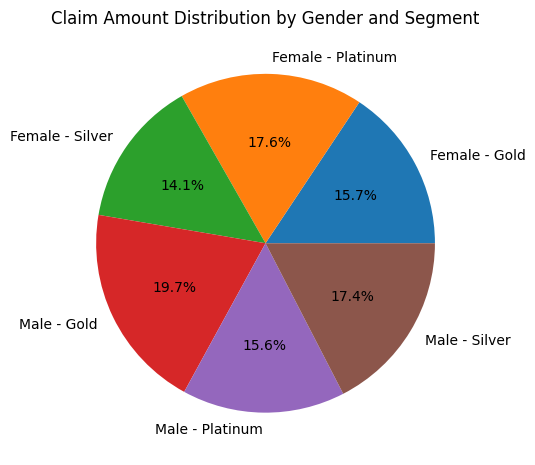

In [178]:
plt.figure(figsize=(5.5,5.5))
plt.pie(grouped['claim_amount'], labels= grouped['label'],autopct= '%1.1f%%')
plt.title("Claim Amount Distribution by Gender and Segment")
plt.show()

In [179]:
# which gender claimed the most for any type of driver related issue

In [181]:
df_driver = df[df['incident_cause'].isin(['Driver error', 'Other driver error'])]

In [182]:
df_driver

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment,Alert_flag,Age,Age_Group
751,25213498,28932340,Driver error,2018-10-30,Auto,Unknown,Material only,12501.726555,1.0,No,Male,1996-01-05,LA,652-265-8231,Gold,0,30,Adult
234,52377605,40480522,Driver error,2018-10-30,Auto,Unknown,Material and injury,26310.000000,1.0,No,Female,1984-05-30,NV,739-259-6835,Gold,0,41,Adult
318,87329176,77510822,Other driver error,2018-10-30,Auto,Unknown,Material only,12501.726555,2.0,No,Female,1986-03-18,AK,436-934-7156,Silver,0,40,Adult
697,32178193,86491727,Driver error,2018-10-30,Home,Unknown,Material only,1860.000000,1.0,No,Female,1997-01-29,IL,294-187-3286,Gold,0,29,Youth
941,74761374,46710738,Driver error,2018-10-30,Auto,No,Material only,1830.000000,1.0,No,Male,1977-04-28,MO,962-834-9361,Gold,0,49,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,97666948,97514724,Driver error,2017-01-01,Home,No,Injury only,19120.000000,1.0,No,Male,1969-06-08,FL,641-684-7986,Platinum,1,56,Adult
379,36457152,25634799,Driver error,2017-01-01,Auto,No,Material only,2900.000000,2.0,No,Female,1974-11-04,KS,724-781-3692,Platinum,0,51,Adult
330,70512964,22756942,Driver error,2017-01-01,Auto,Yes,Injury only,20310.000000,1.0,No,Male,1982-10-09,FL,462-823-3126,Silver,0,43,Adult
739,58878919,29323970,Driver error,2017-01-01,Auto,Unknown,Material only,1840.000000,1.0,Yes,Male,1971-03-03,NE,783-653-9163,Gold,0,55,Adult


In [184]:
result = df_driver.groupby('gender')['claim_amount'].sum()

In [185]:
result

gender
Female    3.136718e+06
Male      3.975412e+06
Name: claim_amount, dtype: float64

In [187]:
result.idxmax()

'Male'

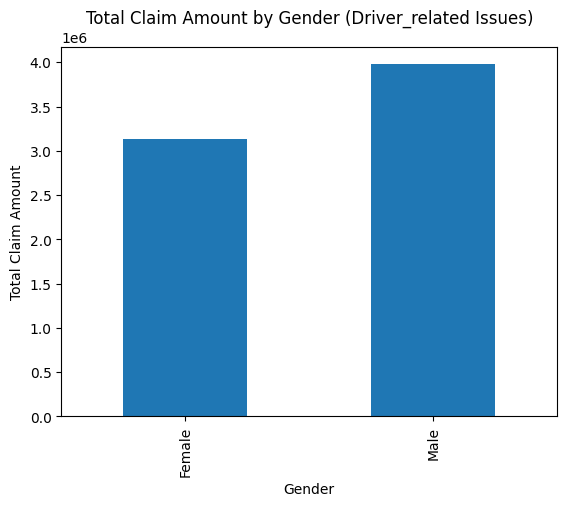

In [191]:
result.plot(kind = 'bar')
plt.title("Total Claim Amount by Gender (Driver_related Issues)")
plt.xlabel("Gender")
plt.ylabel("Total Claim Amount")
plt.show()

In [192]:
df

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment,Alert_flag,Age,Age_Group
751,25213498,28932340,Driver error,2018-10-30,Auto,Unknown,Material only,12501.726555,1.0,No,Male,1996-01-05,LA,652-265-8231,Gold,0,30,Adult
1077,91386759,65208809,Natural causes,2018-10-30,Auto,No,Material only,2290.000000,1.0,No,Male,1964-04-22,VA,286-128-6132,Platinum,0,62,Senior
222,49735712,17682060,Crime,2018-10-30,Home,Unknown,Material and injury,17020.000000,1.0,No,Female,1974-11-21,NV,186-195-3465,Gold,0,51,Adult
234,52377605,40480522,Driver error,2018-10-30,Auto,Unknown,Material and injury,26310.000000,1.0,No,Female,1984-05-30,NV,739-259-6835,Gold,0,41,Adult
282,99775483,93915431,Other causes,2018-10-30,Auto,No,Material and injury,42124.500000,1.0,Yes,Male,1967-09-08,ME,134-785-1687,Gold,0,58,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,58878919,29323970,Driver error,2017-01-01,Auto,Unknown,Material only,1840.000000,1.0,Yes,Male,1971-03-03,NE,783-653-9163,Gold,0,55,Adult
308,9476314,65176092,Other causes,2017-01-01,Auto,No,Material and injury,37290.000000,3.0,No,Male,1975-11-23,NC,651-379-2486,Silver,0,50,Adult
905,42280334,42664554,Other causes,2017-01-01,Auto,No,Injury only,27670.000000,1.0,No,Female,1993-08-13,TN,396-973-2531,Gold,1,32,Adult
191,23636125,64840478,Other driver error,2017-01-01,Auto,Unknown,Material and injury,17290.000000,1.0,No,Female,1974-02-14,NM,918-174-7461,Silver,0,52,Adult


In [193]:
df['fraudulent'].value_counts()

fraudulent
No     833
Yes    245
Name: count, dtype: int64

In [194]:
df_fraud = df[df['fraudulent'] == 'Yes']

In [195]:
df_fraud

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment,Alert_flag,Age,Age_Group
282,99775483,93915431,Other causes,2018-10-30,Auto,No,Material and injury,42124.5,1.0,Yes,Male,1967-09-08,ME,134-785-1687,Gold,0,58,Adult
977,9261301,53042145,Other causes,2018-10-23,Auto,Unknown,Material only,2553.0,4.0,Yes,Female,1964-10-04,TN,139-746-7128,Platinum,0,61,Senior
105,79953107,73456835,Other driver error,2018-10-16,Auto,No,Material only,2599.0,1.0,Yes,Female,1978-12-31,CO,376-294-4612,Silver,0,47,Adult
395,94242984,69065193,Other driver error,2018-10-09,Auto,Unknown,Material and injury,36075.5,4.0,Yes,Female,1980-09-26,MT,963-496-4127,Silver,0,45,Adult
141,32116508,65728108,Other causes,2018-10-09,Auto,Unknown,Material and injury,47610.0,3.0,Yes,Male,1984-11-22,SC,438-675-4587,Platinum,0,41,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,30422665,70088729,Driver error,2017-01-07,Home,No,Material only,1552.5,1.0,Yes,Male,1962-12-06,WI,453-475-2863,Silver,0,63,Senior
208,43722644,36395486,Other causes,2017-01-07,Home,No,Material only,3335.0,3.0,Yes,Male,1971-03-06,ND,365-482-4683,Gold,0,55,Adult
596,18739929,5152503,Crime,2017-01-07,Auto,No,Material only,1759.5,4.0,Yes,Male,1975-08-27,ND,126-721-7382,Silver,0,50,Adult
116,39131766,39587790,Other causes,2017-01-01,Auto,No,Material only,2967.0,1.0,Yes,Male,1965-01-10,LA,615-154-3516,Gold,0,61,Senior


In [198]:
result = df_fraud.groupby('Age_Group', observed=True).size()

In [199]:
result

Age_Group
Youth      17
Adult     185
Senior     43
dtype: int64

In [201]:
result.idxmax()

'Adult'

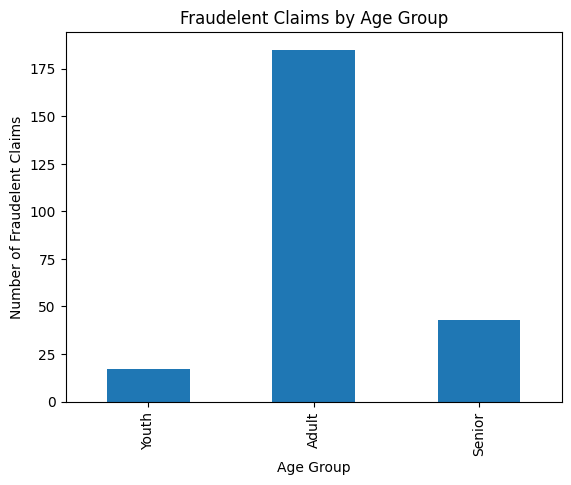

In [203]:
result.plot(kind = 'bar')
plt.title("Fraudelent Claims by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Fraudelent Claims")
plt.show()

In [204]:
# the monthly trend of the total amount that has been claimed by the customers

In [205]:
df['Month'] = df['claim_date'].dt.month

In [206]:
df['Month_Name'] = df['claim_date'].dt.strftime('%b')

In [207]:
df

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment,Alert_flag,Age,Age_Group,Month,Month_Name
751,25213498,28932340,Driver error,2018-10-30,Auto,Unknown,Material only,12501.726555,1.0,No,Male,1996-01-05,LA,652-265-8231,Gold,0,30,Adult,10,Oct
1077,91386759,65208809,Natural causes,2018-10-30,Auto,No,Material only,2290.000000,1.0,No,Male,1964-04-22,VA,286-128-6132,Platinum,0,62,Senior,10,Oct
222,49735712,17682060,Crime,2018-10-30,Home,Unknown,Material and injury,17020.000000,1.0,No,Female,1974-11-21,NV,186-195-3465,Gold,0,51,Adult,10,Oct
234,52377605,40480522,Driver error,2018-10-30,Auto,Unknown,Material and injury,26310.000000,1.0,No,Female,1984-05-30,NV,739-259-6835,Gold,0,41,Adult,10,Oct
282,99775483,93915431,Other causes,2018-10-30,Auto,No,Material and injury,42124.500000,1.0,Yes,Male,1967-09-08,ME,134-785-1687,Gold,0,58,Adult,10,Oct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,58878919,29323970,Driver error,2017-01-01,Auto,Unknown,Material only,1840.000000,1.0,Yes,Male,1971-03-03,NE,783-653-9163,Gold,0,55,Adult,1,Jan
308,9476314,65176092,Other causes,2017-01-01,Auto,No,Material and injury,37290.000000,3.0,No,Male,1975-11-23,NC,651-379-2486,Silver,0,50,Adult,1,Jan
905,42280334,42664554,Other causes,2017-01-01,Auto,No,Injury only,27670.000000,1.0,No,Female,1993-08-13,TN,396-973-2531,Gold,1,32,Adult,1,Jan
191,23636125,64840478,Other driver error,2017-01-01,Auto,Unknown,Material and injury,17290.000000,1.0,No,Female,1974-02-14,NM,918-174-7461,Silver,0,52,Adult,1,Jan


In [212]:
monthly = df.groupby(['Month', 'Month_Name'])['claim_amount'].sum().reset_index()

In [213]:
monthly

,Month,Month_Name,claim_amount
0,1,Jan,1.327171e+06
1,2,Feb,1.164542e+06
2,3,Mar,1.320250e+06
3,4,Apr,1.292514e+06
4,5,May,1.114461e+06
5,6,Jun,1.279030e+06
6,7,Jul,1.379316e+06
7,8,Aug,9.112972e+05
8,9,Sep,9.832003e+05
9,10,Oct,1.409639e+06


In [214]:
monthly = monthly.sort_values('Month')

In [215]:
monthly

,Month,Month_Name,claim_amount
0,1,Jan,1.327171e+06
1,2,Feb,1.164542e+06
2,3,Mar,1.320250e+06
3,4,Apr,1.292514e+06
4,5,May,1.114461e+06
5,6,Jun,1.279030e+06
6,7,Jul,1.379316e+06
7,8,Aug,9.112972e+05
8,9,Sep,9.832003e+05
9,10,Oct,1.409639e+06


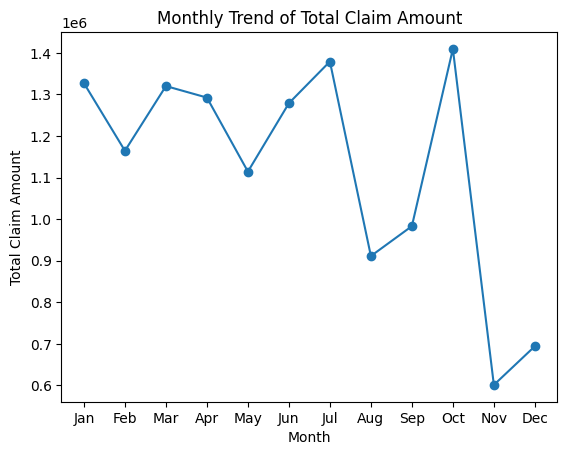

In [219]:
plt.plot(monthly['Month_Name'], monthly['claim_amount'], marker = 'o')
plt.title("Monthly Trend of Total Claim Amount")
plt.xlabel("Month")
plt.ylabel("Total Claim Amount")
plt.show()

In [220]:
# the average claim amount for gender and age categories

In [222]:
df.columns

Index(['claim_id', 'customer_id', 'incident_cause', 'claim_date', 'claim_area',
       'police_report', 'claim_type', 'claim_amount', 'total_policy_claims',
       'fraudulent', 'gender', 'DateOfBirth', 'State', 'Contact', 'Segment',
       'Alert_flag', 'Age', 'Age_Group', 'Month', 'Month_Name'],
      dtype='object')

In [225]:
avg_claim = df.groupby(['fraudulent', 'gender', 'Age_Group'], observed = True)['claim_amount'].mean().reset_index()

In [226]:
avg_claim

,fraudulent,gender,Age_Group,claim_amount
0,No,Female,Youth,10190.572027
1,No,Female,Adult,12670.557552
2,No,Female,Senior,12561.181736
3,No,Male,Youth,13027.486805
4,No,Male,Adult,12360.307749
5,No,Male,Senior,11685.862147
6,Yes,Female,Youth,7229.187500
7,Yes,Female,Adult,12889.486435
8,Yes,Female,Senior,6204.692308
9,Yes,Male,Youth,11397.914062


In [227]:
avg_claim.head()

,fraudulent,gender,Age_Group,claim_amount
0,No,Female,Youth,10190.572027
1,No,Female,Adult,12670.557552
2,No,Female,Senior,12561.181736
3,No,Male,Youth,13027.486805
4,No,Male,Adult,12360.307749


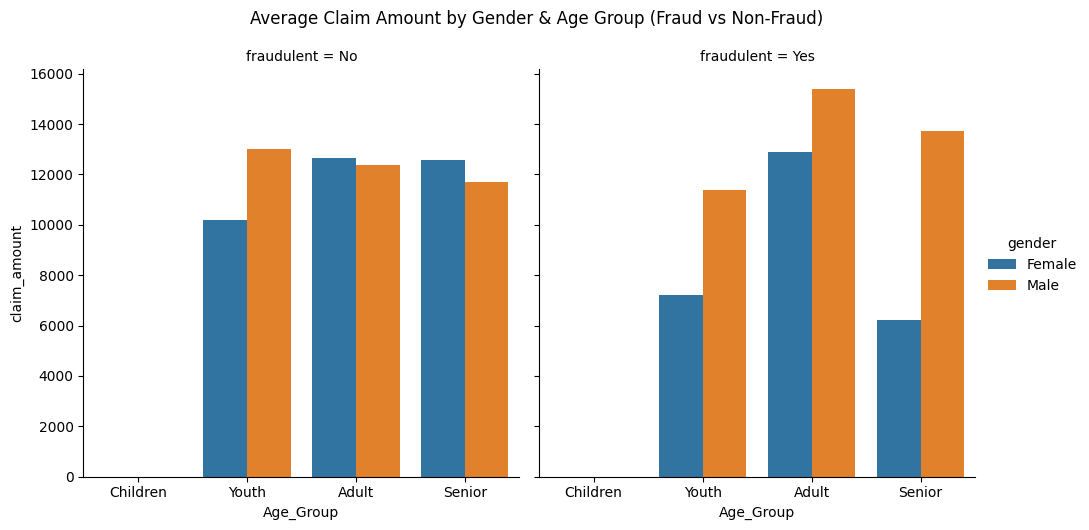

In [236]:
g = sns.catplot(
    data=avg_claim,
    x='Age_Group',
    y='claim_amount',
    hue='gender',
    col='fraudulent',
    kind='bar'
)

g.fig.suptitle("Average Claim Amount by Gender & Age Group (Fraud vs Non-Fraud)", y=1.05)
plt.show()

In [237]:
# Hypothesis Testing

In [238]:
male_claims = df[df['gender'] == 'Male']['claim_amount']

In [239]:
male_claims

751     12501.726555
1077     2290.000000
282     42124.500000
941      1830.000000
1055     2420.000000
            ...     
116      2967.000000
330     20310.000000
739      1840.000000
308     37290.000000
173      2080.000000
Name: claim_amount, Length: 551, dtype: float64

In [242]:
female_claims = df[df['gender'] == 'Female']['claim_amount']

In [243]:
female_claims

222     17020.000000
234     26310.000000
318     12501.726555
350      1940.000000
697      1860.000000
            ...     
177     30930.000000
379      2900.000000
1064    20630.000000
905     27670.000000
191     17290.000000
Name: claim_amount, Length: 527, dtype: float64

In [244]:
from scipy.stats import ttest_ind

In [245]:
t_stat, p_value = ttest_ind(male_claims, female_claims, nan_policy= 'omit')
print("T-statistic:", t_stat)
print("p-value:", p_value)

T-statistic: 0.9625093446632118
p-value: 0.33601006135365463


In [ ]:
# if p-value < 0.05 ----> reject Ho
# if p-value > 0.05 ----> Fail to reject Ho

In [249]:
''' As p_value > 0.05 
Hence The difference in claim amounts between males and females is NOT statistically significant'''


' As p_value > 0.05 \nHence The difference in claim amounts between males and females is NOT statistically significant'

In [251]:
# Relationship between age category and segment ---> Chi-Square Test

In [252]:
cont_table = pd.crosstab(df['Age_Group'], df['Segment'])

In [253]:
cont_table

Segment,Gold,Platinum,Silver
Age_Group,,,
Youth,34,31,38
Adult,281,271,257
Senior,56,59,51


In [256]:
from scipy.stats import chi2_contingency
chi2, p_value, dof, expected = chi2_contingency(cont_table)
print("Chi_square:", chi2)
print("P-value:", p_value)

Chi_square: 1.5314185203946333
P-value: 0.8210618779293812


In [257]:
'''As p-value is less than 0.05
Hence we fail to reject Null Hypothesis (Ho)
Hence there is no relationship between Age group and Segment'''

'As p-value is less than 0.05\nHence we fail to reject Null Hypothesis (Ho)\nHence there is no relationship between Age group and Segment'

In [258]:
# The current year has shown a significant rise in claim amounts as compared to 2016-17 fiscal average which was $10,000.


In [261]:
df_current = df[df['claim_date'].dt.year == 2018]['claim_amount']

In [268]:
from scipy.stats import ttest_1samp
t_stat, p_value = ttest_1samp(df_current, 10000)

p_value = p_value/2

print("T-Statistic:", t_stat)
print("P_value:", format(p_value, '.7f'))

T-Statistic: 4.477343563243787
P_value: 0.0000047


In [269]:
# p_value < 0.05, Hence we reject null hypothesis
# The current year claim amount is significantly higher than 10,000